Using the matrix inverse method

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [9]:
#initialize the graph
sess = tf.Session()
x_vals = np.linspace(0, 10, 100)
y_vals = x_vals + np.random.normal(0, 1,100)

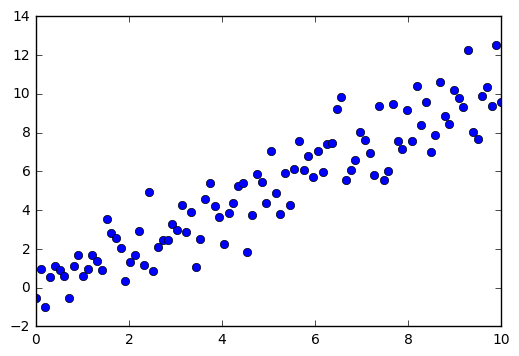

In [10]:
#plot to check generated data
plt.plot(x_vals, y_vals, 'o', label = 'Data')
plt.show()

In [11]:
#create the matrix to use inverse method
x_vals_column = np.transpose(np.matrix(x_vals))
ones_column = np.transpose(np.matrix(np.repeat(1, 100)))
A = np.column_stack((x_vals_column, ones_column))# A is a matrix with a column of x_data and a column of 1s
b = np.transpose(np.matrix(y_vals))

In [12]:
#turn matrix A and b to tensor
A_tensor = tf.constant(A)
b_tensor = tf.constant(b)

In [13]:
#solve the problem with inverse method
#x = (A_t * A)^-1 * A_T *b
At_A = tf.matmul(tf.transpose(A_tensor), A_tensor)
At_A_inv = tf.matrix_inverse(At_A)
product = tf.matmul(At_A_inv, tf.transpose(A_tensor))
solution = tf.matmul(product, b_tensor)
solution_eval = sess.run(solution)

In [14]:
#extract the coefficients from solution
slope = solution_eval[0][0]
y_intercept = solution_eval[1][0]
print('Slope = ' +str(slope))
print('y_intercept = ' + str(y_intercept))

Slope = 1.04363502417
y_intercept = -0.0503318605502


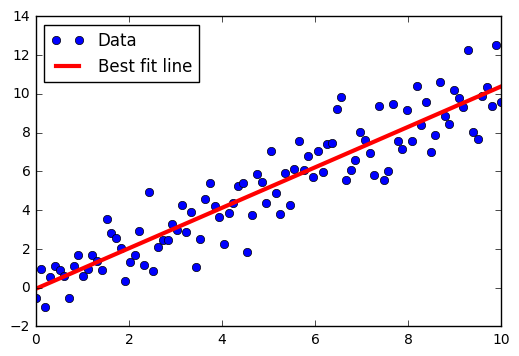

In [15]:
#draw the line
best_fit = []
for i in x_vals:
    best_fit.append(slope*i+y_intercept)
plt.plot(x_vals, y_vals, 'o', label = 'Data')
plt.plot(x_vals, best_fit, 'r', label = 'Best fit line', linewidth = 3)
plt.legend(loc = 'upper left')
plt.show()
sess.close()

Implementing a Decomposition Method

In [16]:
#first few line is the same as above
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

#initialize the graph
sess = tf.Session()
x_vals = np.linspace(0, 10, 100)
y_vals = x_vals + np.random.normal(0, 1,100)

#create the matrix to use inverse method
x_vals_column = np.transpose(np.matrix(x_vals))
ones_column = np.transpose(np.matrix(np.repeat(1, 100)))
A = np.column_stack((x_vals_column, ones_column))# A is a matrix with a column of x_data and a column of 1s
b = np.transpose(np.matrix(y_vals))

#turn matrix A and b to tensor
A_tensor = tf.constant(A)
b_tensor = tf.constant(b)
y = np.transpose(np.matrix(y_vals))

In [17]:
# Find Cholesky Decomposition
tA_A = tf.matmul(tf.transpose(A_tensor), A_tensor)
L = tf.cholesky(tA_A)
# Solve L*y=t(A)*b
tA_y = tf.matmul(tf.transpose(A_tensor), y)
sol1 = tf.matrix_solve(L, tA_y)
# Solve L' * y = sol1
sol2 = tf.matrix_solve(tf.transpose(L), sol1)
solution_eval = sess.run(sol2)

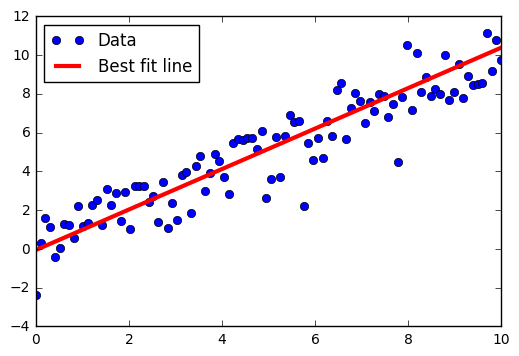

In [18]:
#draw the line
best_fit = []
for i in x_vals:
    best_fit.append(slope*i+y_intercept)
plt.plot(x_vals, y_vals, 'o', label = 'Data')
plt.plot(x_vals, best_fit, 'r', label = 'Best fit line', linewidth = 3)
plt.legend(loc = 'upper left')
plt.show()
sess.close()

Learning the TensorFlow Way of Linear Regression

Understanding Loss function in Linear Regression

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn import datasets
from tensorflow.python.framework import ops
ops.reset_default_graph()

In [30]:
sess = tf.Session()
iris = datasets.load_iris()

x_vals = np.array([x[3] for x in iris.data])
y_vals = np.array([y[0] for y in iris.data])

In [31]:
#declare our learning rate,bathh size, placeholder
learning_rate = 0.05
batch_size = 25
x_data = tf.placeholder(shape = [None,1], dtype = tf.float32)
y_target = tf.placeholder(shape = [None,1], dtype = tf.float32)
A = tf.Variable(tf.random_normal(shape = [1,1]))
b = tf.Variable(tf.random_normal(shape = [1,1]))

In [32]:
#Linear Model
model_output = tf.add(tf.matmul(x_data, A), b)

In [33]:
#declare L2 loss function for the first task
#loss = tf.reduce_mean(tf.square(y_target - model_output))
#declare L1 loss function for the second task
loss = tf.reduce_mean(tf.abs(y_target - model_output))
init = tf.global_variables_initializer()
sess.run(init)
my_opt = tf.train.GradientDescentOptimizer(learning_rate)
train_step = my_opt.minimize(loss)

In [34]:
#Train the model
loss_vec = []
for i in range(100):
    rand_index = np.random.choice(len(x_vals), size=batch_size)
    rand_x = np.transpose([x_vals[rand_index]])
    rand_y = np.transpose([y_vals[rand_index]])
    sess.run(train_step, feed_dict={x_data: rand_x, y_target: rand_y})
    temp_loss = sess.run(loss, feed_dict={x_data: rand_x, y_target: rand_y})
    loss_vec.append(temp_loss)
    if(i+1) %25==0:
        print('Step #' + str(i+1) + ' A = ' + str(sess.run(A)) + ' b = ' + str(sess.run(b)))
        print('Loss = ' + str(temp_loss))

Step #25 A = [[ 0.31224278]] b = [[-1.11624146]]
Loss = 6.64209
Step #50 A = [[ 1.7858429]] b = [[ 0.1337586]]
Loss = 3.88155
Step #75 A = [[ 2.86204386]] b = [[ 1.19575858]]
Loss = 1.93014
Step #100 A = [[ 2.87204385]] b = [[ 1.7097584]]
Loss = 1.14663


In [35]:
#extract the coefficients + create a best-fit line
[slope] = sess.run(A)
[y_intercept] = sess.run(b)
best_fit = []
for i in x_vals:
    best_fit.append(slope*i + y_intercept)

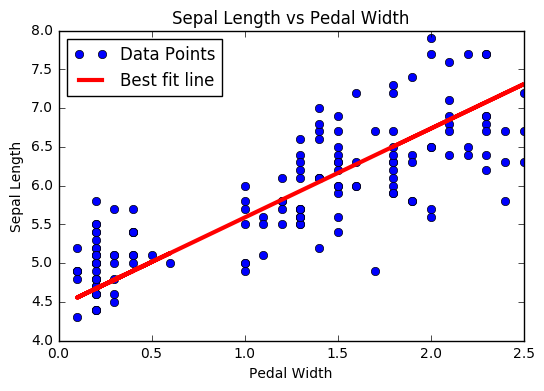

In [27]:
#plot the result
plt.plot(x_vals, y_vals, 'o', label='Data Points')
plt.plot(x_vals, best_fit, 'r-', label='Best fit line', linewidth=3)
plt.legend(loc='upper left')
plt.title('Sepal Length vs Pedal Width')
plt.xlabel('Pedal Width')
plt.ylabel('Sepal Length')
plt.show()

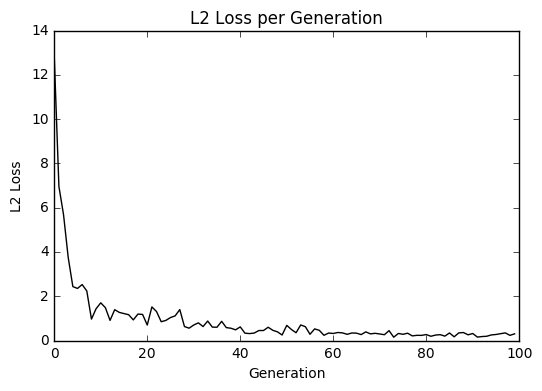

In [28]:
#plot the error
plt.plot(loss_vec, 'k-')
plt.title('L2 Loss per Generation')
plt.xlabel('Generation')
plt.ylabel('L2 Loss')
plt.show()

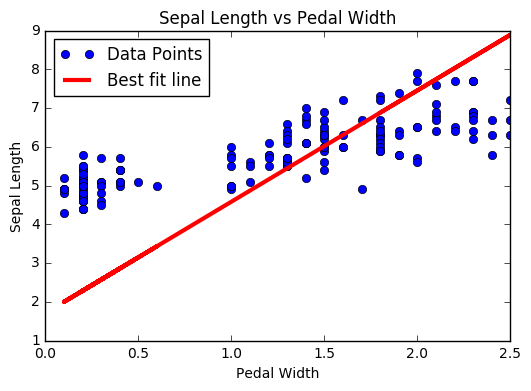

In [36]:
#plot the result
plt.plot(x_vals, y_vals, 'o', label='Data Points')
plt.plot(x_vals, best_fit, 'r-', label='Best fit line', linewidth=3)
plt.legend(loc='upper left')
plt.title('Sepal Length vs Pedal Width')
plt.xlabel('Pedal Width')
plt.ylabel('Sepal Length')
plt.show()

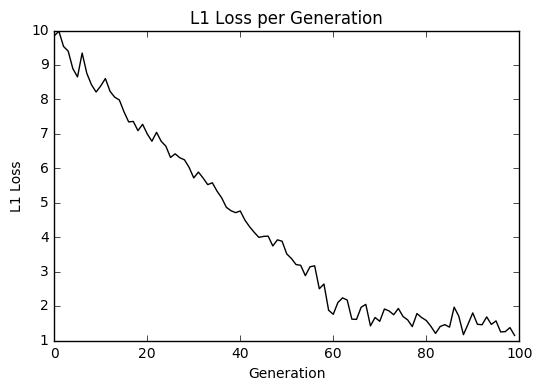

In [37]:
#plot the error
plt.plot(loss_vec, 'k-')
plt.title('L1 Loss per Generation')
plt.xlabel('Generation')
plt.ylabel('L1 Loss')
plt.show()

Implementing other kind of regression

It is unnecessary to implement it, so leave it for other time